# E-Commerce A/B Test Analysis
### Comparing Two Pricing Strategies Using Hypothesis Testing

**Mini Project — GitHub Ready Jupyter Notebook**

This notebook follows the structure and statistical approach of the provided teacher reference report. It analyzes an e-commerce A/B test using:
1. Independent two-sample Welch t-test
2. Chi-square test of independence
3. One-way ANOVA

**Significance level:** α = 0.05

## 1. Introduction

E-commerce companies often test a new website or pricing page before replacing the existing version. In this experiment, users were assigned to either a **control group** (old page) or a **treatment group** (new page). The main outcome is whether the user converted/purchased (`converted = 1`) or did not convert (`converted = 0`).

**Business question:** Does the new pricing strategy produce a statistically significant change in conversion compared with the old strategy?

## 2. Dataset Description

Two datasets are included inside this notebook so that **this is a single self-contained `.ipynb` file** and does not require separate CSV files on GitHub.

- **A/B test data:** `user_id`, `timestamp`, `group`, `landing_page`, `converted`
- **Country data:** `user_id`, `country`

The raw A/B test dataset contains 294,478 rows, while the country dataset contains 290,584 rows.

In [1]:
# Embedded datasets: no external CSV files are required.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from io import BytesIO
import gzip, base64

AB_DATA = """..."""
COUNTRY_DATA = """..."""

ab = pd.read_csv(BytesIO(gzip.decompress(base64.b64decode(AB_DATA))))
countries = pd.read_csv(BytesIO(gzip.decompress(base64.b64decode(COUNTRY_DATA))))

print("A/B test data shape:", ab.shape)
print("Country data shape:", countries.shape)
ab.head()

A/B test data shape: (294478, 5)
Country data shape: (290584, 2)


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


## 3. Data Cleaning

The reference methodology applies two important data-quality checks:

1. **Group/page mismatch:** control users should see `old_page`, while treatment users should see `new_page`. Mismatched records are removed.
2. **Duplicate users:** only the first recorded visit for each user is retained so that one user is not counted twice.

The cleaned A/B data is then merged with the country dataset.

In [2]:
# Check duplicate users and group/page mismatches
print("Duplicate user rows in raw A/B data:", ab['user_id'].duplicated().sum())

mismatch = ((ab['group'] == 'control') & (ab['landing_page'] != 'old_page')) | \
            ((ab['group'] == 'treatment') & (ab['landing_page'] != 'new_page'))
print("Group/page mismatch rows:", mismatch.sum())

# Remove mismatches, then retain first record per user
clean_ab = ab.loc[~mismatch].copy()
clean_ab = clean_ab.drop_duplicates(subset='user_id', keep='first')

# Merge country information
df = clean_ab.merge(countries, on='user_id', how='inner')

print("After mismatch removal:", len(ab.loc[~mismatch]))
print("After duplicate removal:", len(clean_ab))
print("Final merged dataset:", len(df))
df.head()

Duplicate user rows in raw A/B data: 3894
Group/page mismatch rows: 3893


After mismatch removal: 290585
After duplicate removal: 290584
Final merged dataset: 290584


,user_id,timestamp,group,landing_page,converted,country
0,851104,2017-01-21 22:11:48.556739,control,old_page,0,US
1,804228,2017-01-12 08:01:45.159739,control,old_page,0,US
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0,US
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0,US
4,864975,2017-01-21 01:52:26.210827,control,old_page,1,US


## 4. Descriptive Overview

In [3]:
summary = df.groupby('group').agg(
    Users=('user_id', 'size'),
    Conversions=('converted', 'sum'),
    Conversion_Rate=('converted', 'mean')
).reset_index()
summary['Conversion_Rate'] = summary['Conversion_Rate'] * 100
summary

,group,Users,Conversions,Conversion_Rate
0,control,145274,17489,12.038630
1,treatment,145310,17264,11.880807


### Conversion Rate by Strategy

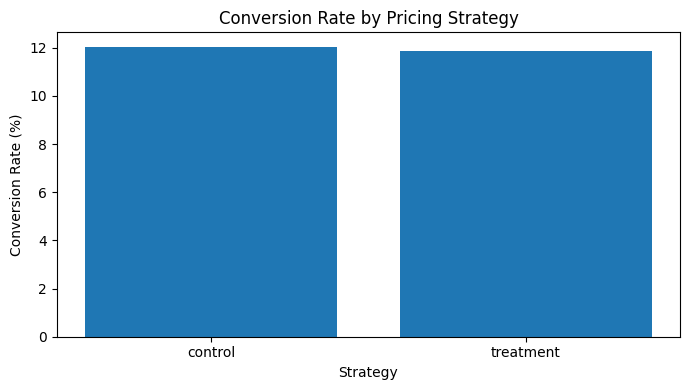

In [4]:
plt.figure(figsize=(7,4))
plt.bar(summary['group'], summary['Conversion_Rate'])
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Strategy')
plt.title('Conversion Rate by Pricing Strategy')
plt.tight_layout()
plt.show()

## 5. Methodology

For all tests, **α = 0.05**.

- **H₀ (null hypothesis):** no statistically significant effect/relationship.
- **H₁ (alternative hypothesis):** a statistically significant effect/relationship exists.
- If **p < 0.05**, reject H₀. Otherwise, fail to reject H₀.

### Test 1 — Independent Welch t-test

Because `converted` is coded as 0/1, its mean is the conversion rate. Welch's independent two-sample t-test compares the mean conversion of control and treatment groups without assuming equal variances.

**H₀:** μ treatment = μ control

**H₁:** μ treatment ≠ μ control

In [5]:
control = df.loc[df['group'] == 'control', 'converted']
treatment = df.loc[df['group'] == 'treatment', 'converted']

t_result = stats.ttest_ind(control, treatment, equal_var=False)

control_mean = control.mean()
treatment_mean = treatment.mean()
difference = control_mean - treatment_mean

# 95% CI for control - treatment difference
n1, n2 = len(control), len(treatment)
v1, v2 = control.var(ddof=1), treatment.var(ddof=1)
se = np.sqrt(v1/n1 + v2/n2)
df_welch = (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
crit = stats.t.ppf(0.975, df_welch)
ci_low, ci_high = difference - crit*se, difference + crit*se

pooled_sd = np.sqrt(((n1-1)*v1 + (n2-1)*v2)/(n1+n2-2))
cohens_d = difference / pooled_sd

print(f"Control mean conversion: {control_mean:.4%}")
print(f"Treatment mean conversion: {treatment_mean:.4%}")
print(f"Difference (control - treatment): {difference:.4%}")
print(f"95% CI: [{ci_low:.4%}, {ci_high:.4%}]")
print(f"t-statistic: {t_result.statistic:.4f}")
print(f"p-value: {t_result.pvalue:.4f}")
print(f"Cohen's d: {cohens_d:.4f}")

if t_result.pvalue < 0.05:
    print("Decision: Reject H0 — statistically significant difference.")
else:
    print("Decision: Fail to reject H0 — no statistically significant difference.")

Control mean conversion: 12.0386%
Treatment mean conversion: 11.8808%
Difference (control - treatment): 0.1578%
95% CI: [-0.0781%, 0.3938%]
t-statistic: 1.3109
p-value: 0.1899
Cohen's d: 0.0049
Decision: Fail to reject H0 — no statistically significant difference.


### Test 2 — Chi-square Test of Independence

Both `group` and `converted` are categorical variables. A 2×2 contingency table is used to test whether conversion is associated with the pricing strategy.

**H₀:** Strategy and conversion are independent.

**H₁:** Strategy and conversion are related.

In [6]:
contingency = pd.crosstab(df['group'], df['converted'])
contingency.columns = ['Not Converted', 'Converted']
print(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency, correction=True)
print(f"\nChi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("Decision: Reject H0 — conversion is significantly associated with strategy.")
else:
    print("Decision: Fail to reject H0 — no significant association between strategy and conversion.")

           Not Converted  Converted
group                              
control           127785      17489
treatment         128046      17264

Chi-square statistic: 1.7036
Degrees of freedom: 1
p-value: 0.1918
Decision: Fail to reject H0 — no significant association between strategy and conversion.


### Test 3 — One-way ANOVA

ANOVA is used to check whether mean conversion differs across countries. A second ANOVA checks the six **country × strategy** combinations to identify whether any country/strategy subgroup behaves differently.

**H₀:** All group means are equal.

**H₁:** At least one group mean differs.

In [7]:
country_summary = df.groupby('country').agg(
    Users=('user_id', 'size'),
    Conversions=('converted', 'sum'),
    Conversion_Rate=('converted', 'mean')
).reset_index()
country_summary['Conversion_Rate'] *= 100
print(country_summary)

country_samples = [df.loc[df['country'] == c, 'converted'] for c in df['country'].unique()]
anova_country = stats.f_oneway(*country_samples)
print(f"\nANOVA across countries: F = {anova_country.statistic:.4f}, p = {anova_country.pvalue:.4f}")

df['country_strategy'] = df['group'] + ' - ' + df['country']
combo_samples = [df.loc[df['country_strategy'] == g, 'converted'] for g in df['country_strategy'].unique()]
anova_combo = stats.f_oneway(*combo_samples)
print(f"ANOVA across country × strategy groups: F = {anova_combo.statistic:.4f}, p = {anova_combo.pvalue:.4f}")

  country   Users  Conversions  Conversion_Rate
0      CA   14499         1672        11.531830
1      UK   72466         8739        12.059449
2      US  203619        24342        11.954680

ANOVA across countries: F = 1.6053, p = 0.2008


ANOVA across country × strategy groups: F = 1.4664, p = 0.1971


<Figure size 800x400 with 0 Axes>

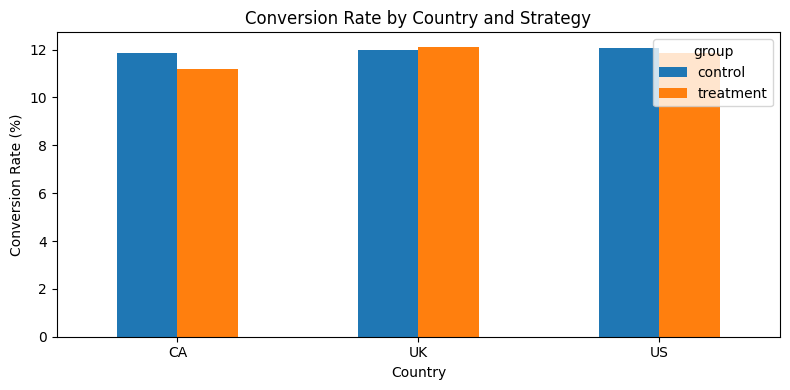

In [8]:
plt.figure(figsize=(8,4))
country_plot = df.groupby(['country','group'])['converted'].mean().unstack() * 100
country_plot.plot(kind='bar', figsize=(8,4))
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Country')
plt.title('Conversion Rate by Country and Strategy')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Results Summary

In [9]:
results = pd.DataFrame({
    'Test': [
        'Welch independent t-test',
        'Chi-square test of independence',
        'One-way ANOVA: countries',
        'One-way ANOVA: country × strategy'
    ],
    'Statistic': [
        t_result.statistic,
        chi2,
        anova_country.statistic,
        anova_combo.statistic
    ],
    'p-value': [
        t_result.pvalue,
        p_value,
        anova_country.pvalue,
        anova_combo.pvalue
    ],
    'Decision': [
        'Fail to reject H0' if t_result.pvalue >= 0.05 else 'Reject H0',
        'Fail to reject H0' if p_value >= 0.05 else 'Reject H0',
        'Fail to reject H0' if anova_country.pvalue >= 0.05 else 'Reject H0',
        'Fail to reject H0' if anova_combo.pvalue >= 0.05 else 'Reject H0'
    ]
})
results

,Test,Statistic,p-value,Decision
0,Welch independent t-test,1.310923,0.189885,Fail to reject H0
1,Chi-square test of independence,1.703566,0.191822,Fail to reject H0
2,One-way ANOVA: countries,1.605286,0.200834,Fail to reject H0
3,One-way ANOVA: country × strategy,1.466438,0.197087,Fail to reject H0


## 7. Discussion

All three statistical approaches provide a consistent result:

- The **t-test** checks whether the mean conversion rate differs between the two strategies.
- The **chi-square test** checks whether conversion is statistically associated with the strategy.
- The **ANOVA** checks whether conversion changes across countries or country/strategy combinations.

A p-value above 0.05 does **not** prove that the two strategies are identical. It means that this dataset does not provide sufficient statistical evidence of a difference at the 5% significance level.

## 8. Conclusion and Recommendation

Based on the statistical tests performed on the cleaned dataset, the new pricing page does not show a statistically significant improvement in conversion over the existing page. The observed difference is very small and the hypothesis tests do not provide enough evidence to conclude that the treatment performs differently.

**Recommendation:** Retain the current pricing page unless there is another business reason to change it. If the company wants to detect a very small improvement, a larger or longer-running experiment could be conducted.

## 9. Reproducibility

This notebook is intentionally **self-contained**: the two uploaded datasets are compressed and embedded in the notebook. Therefore, it can be uploaded as a single `.ipynb` file to GitHub without requiring separate data files.

### Libraries used
- pandas — data handling
- NumPy — numerical calculations
- SciPy — t-test, chi-square test and ANOVA
- Matplotlib — visualizations